# Candidate Data Exploratory Data Analysis (EDA)

This notebook provides a detailed EDA on the `candidates.jsonl` dataset to analyze the candidate profiles, career history, education, skills, certifications, and languages. It is organized into the following sections:

1. **Data Loading & Deep Flattening**
2. **Location & Country Analysis** (Items 1 & 2)
3. **Career History Date & Duration Validation** (Item 5)
4. **Years of Experience vs. Career Duration Mismatch** (Item 3)
5. **Current Employment Profiles** (Item 4)
6. **Taxonomy Analysis: Company, Title & Industry Types** (Item 6)
7. **Education Analysis: Degree & Field of Study** (Item 7)
8. **Skills Analysis** (Item 8)
9. **Certifications & Languages Analysis** (Item 9)
10. **Redrob Signals Overview & Summary Statistics**
11. **Date Validation: Signup vs. Last Active**
12. **Financial Metrics: Expected Salary Ranges**
13. **Activity & Performance Rates**
14. **Categorical Preferences & Profile Verification Flags**
15. **Skill Assessments Deep-Dive**
16. **Redrob Signals Correlation & Logical Anomalies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading & Flattening

In [2]:
def flatten_candidate(c):
    flat = {'candidate_id': c.get('candidate_id')}
    
    # Profile
    profile = c.get('profile', {})
    for k, v in profile.items():
        flat[f'profile_{k}'] = v
        
    # Redrob Signals
    signals = c.get('redrob_signals', {})
    for k, v in signals.items():
        if k == 'expected_salary_range_inr_lpa':
            flat['expected_salary_min'] = v.get('min') if isinstance(v, dict) else None
            flat['expected_salary_max'] = v.get('max') if isinstance(v, dict) else None
        elif k == 'skill_assessment_scores':
            scores = list(v.values()) if isinstance(v, dict) else []
            flat['signal_assessments_taken'] = len(scores)
            flat['signal_avg_assessment_score'] = sum(scores) / len(scores) if scores else None
            # Keep dictionary for detailed analysis
            flat['skill_assessment_scores'] = v
        else:
            flat[f'signal_{k}'] = v
            
    # Store arrays directly for deep analysis
    flat['career_history'] = c.get('career_history', [])
    flat['education'] = c.get('education', [])
    flat['skills'] = c.get('skills', [])
    flat['certifications'] = c.get('certifications', [])
    flat['languages'] = c.get('languages', [])
    
    # Quick stats
    flat['num_jobs'] = len(flat['career_history'])
    flat['num_degrees'] = len(flat['education'])
    flat['num_skills'] = len(flat['skills'])
    flat['num_certifications'] = len(flat['certifications'])
    flat['num_languages'] = len(flat['languages'])
    
    return flat

def load_data(filepath, sample_size=None):
    records = []
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if sample_size and i >= sample_size:
                break
            records.append(flatten_candidate(json.loads(line)))
    return pd.DataFrame(records)

filepath = 'candidates.jsonl'
if not os.path.exists(filepath) and os.path.exists('../candidates.jsonl'):
    filepath = '../candidates.jsonl'

df = load_data(filepath, sample_size=None)
print(f"Loaded {len(df)} records with {len(df.columns)} base features.")

Loaded 100000 records with 47 base features.


## 2. Location & Country Analysis (Items 1 & 2)

--- Top 10 Countries ---
profile_country
India        75113
USA           9978
Australia     2579
Canada        2506
UK            2472
Germany       2469
Singapore     2453
UAE           2430
Name: count, dtype: int64

--- Top 15 Locations ---
profile_location
Bhubaneswar, Odisha       4321
Noida, Uttar Pradesh      4283
Hyderabad, Telangana      4283
Jaipur, Rajasthan         4268
Bangalore, Karnataka      4238
Kolkata, West Bengal      4230
Indore, Madhya Pradesh    4198
Pune, Maharashtra         4186
Chennai, Tamil Nadu       4164
Delhi, Delhi              4161
Trivandrum, Kerala        4151
Ahmedabad, Gujarat        4143
Chandigarh, Chandigarh    4128
Coimbatore, Tamil Nadu    4113
Vizag, Andhra Pradesh     4093
Name: count, dtype: int64


C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\433542600.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.head(10).values, y=country_counts.head(10).index, ax=axes[0], palette="viridis")
C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\433542600.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.head(15).values, y=location_counts.head(15).index, ax=axes[1], palette="magma")


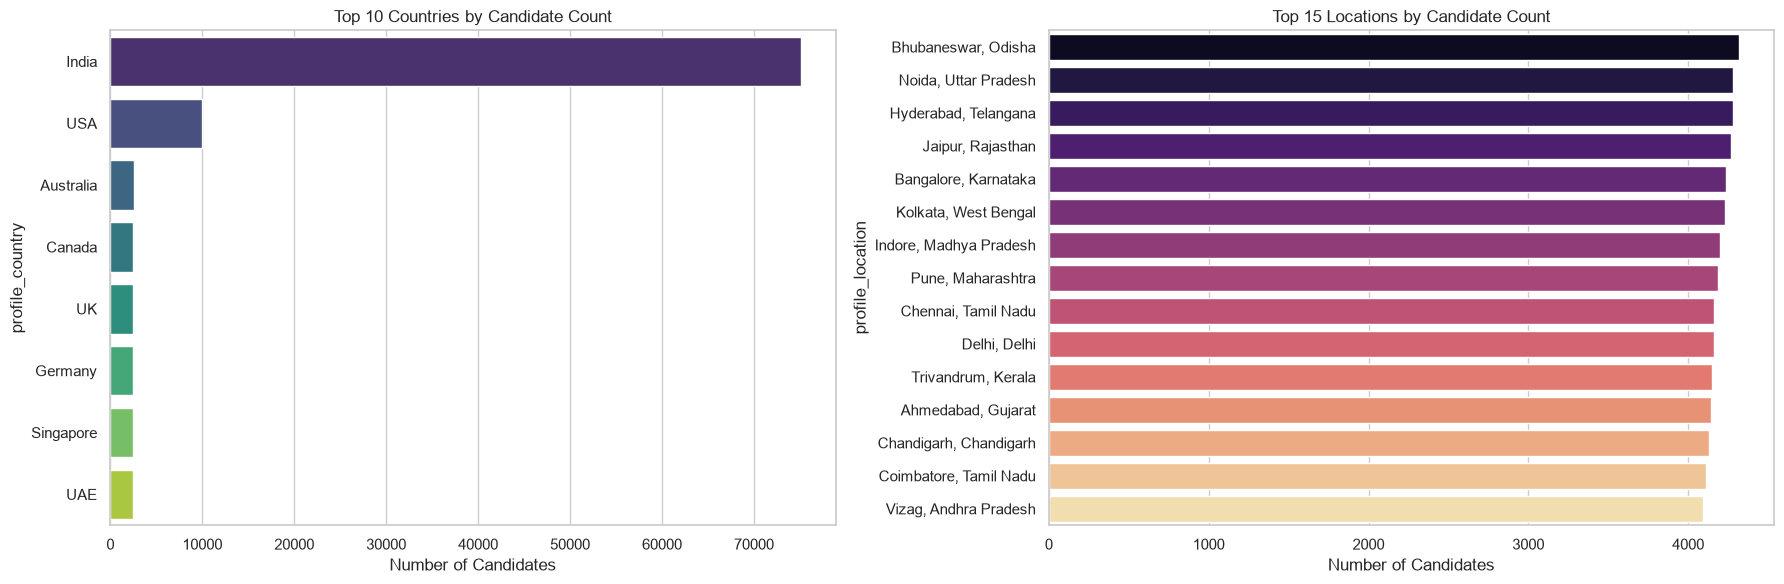

In [3]:
# Country distribution
country_counts = df['profile_country'].value_counts()
print("--- Top 10 Countries ---")
print(country_counts.head(10))

# Location distribution
location_counts = df['profile_location'].value_counts()
print("\n--- Top 15 Locations ---")
print(location_counts.head(15))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x=country_counts.head(10).values, y=country_counts.head(10).index, ax=axes[0], palette="viridis")
axes[0].set_title('Top 10 Countries by Candidate Count')
axes[0].set_xlabel('Number of Candidates')

sns.barplot(x=location_counts.head(15).values, y=location_counts.head(15).index, ax=axes[1], palette="magma")
axes[1].set_title('Top 15 Locations by Candidate Count')
axes[1].set_xlabel('Number of Candidates')
plt.tight_layout()
plt.show()

## 3. Career History Date & Duration Validation (Item 5)

We will verify:
1. If `end_date` is null, `is_current` is true, and vice versa.
2. If the duration computed from `start_date` and `end_date` matches the declared `duration_months` for non-current jobs.

In [4]:
def validate_career_history(career_list):
    is_current_null_end_violations = 0
    duration_mismatches = 0
    total_duration_field = 0
    
    for job in career_list:
        start_str = job.get('start_date')
        end_str = job.get('end_date')
        is_current = job.get('is_current')
        declared_duration = job.get('duration_months', 0)
        
        total_duration_field += declared_duration
        
        # Check is_current and end_date consistency
        if (end_str is None) != is_current:
            is_current_null_end_violations += 1
            
        # Check start/end dates match declared duration (only for non-current jobs)
        if start_str and end_str:
            try:
                start_dt = datetime.strptime(start_str, '%Y-%m-%d')
                end_dt = datetime.strptime(end_str, '%Y-%m-%d')
                
                # Compute duration in days and convert to approximate months
                # Since month lengths vary, we compare with a tolerance of 1 month
                days_diff = (end_dt - start_dt).days
                computed_months = round(days_diff / 30.437)
                
                if abs(computed_months - declared_duration) > 1:
                    duration_mismatches += 1
            except Exception:
                pass
                
    return pd.Series({
        'is_current_violations': is_current_null_end_violations,
        'duration_mismatches': duration_mismatches,
        'total_duration_field': total_duration_field
    })

validation_df = df['career_history'].apply(validate_career_history)
df = pd.concat([df, validation_df], axis=1)

print(f"Total Profiles with is_current vs end_date inconsistencies: {df['is_current_violations'].gt(0).sum()}")
print(f"Total Profiles with start/end date duration mismatches (>1 month): {df['duration_mismatches'].gt(0).sum()}")

Total Profiles with is_current vs end_date inconsistencies: 0
Total Profiles with start/end date duration mismatches (>1 month): 0


## 4. Years of Experience vs. Career Duration Mismatch (Item 3)

We will compare the profile's declared `years_of_experience` (converted to months) with the sum of job durations in their career history.

In [5]:
df['declared_exp_months'] = df['profile_years_of_experience'] * 12
df['experience_difference'] = df['declared_exp_months'] - df['total_duration_field']

# Mismatch where discrepancy > 3 months (allowing slight rounding differences)
mismatch_mask = df['experience_difference'].abs() > 3
mismatched_candidates = df[mismatch_mask]

print(f"Total Candidates with experience discrepancy (> 3 months): {len(mismatched_candidates)} ({len(mismatched_candidates)/len(df)*100:.2f}%)")
print("\n--- First 10 Candidates with Experience Mismatch ---")
print(mismatched_candidates[['candidate_id', 'profile_years_of_experience', 'total_duration_field', 'experience_difference']].head(10))

Total Candidates with experience discrepancy (> 3 months): 2175 (2.17%)

--- First 10 Candidates with Experience Mismatch ---
     candidate_id  profile_years_of_experience  total_duration_field  \
33   CAND_0000034                         14.5                   170   
44   CAND_0000045                         12.2                   143   
83   CAND_0000084                         10.6                   124   
99   CAND_0000100                         13.5                   158   
143  CAND_0000144                         14.7                   173   
239  CAND_0000240                         13.3                   156   
339  CAND_0000340                         11.7                   137   
370  CAND_0000371                         15.0                   176   
385  CAND_0000386                          9.6                   112   
427  CAND_0000428                         14.1                   166   

     experience_difference  
33                     4.0  
44                     

## 5. Current Employment Profiles (Item 4)

Analyzing current titles, companies, company sizes, and industries.

C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\835332854.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=title_counts.values, y=title_counts.index, ax=axes[0, 0], palette="Blues_r")
C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\835332854.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=company_counts.values, y=company_counts.index, ax=axes[0, 1], palette="Greens_r")
C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\835332854.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_counts.index, y=size_counts.values, ax=a

C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\835332854.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.values, y=industry_counts.index, ax=axes[1, 1], palette="Oranges_r")


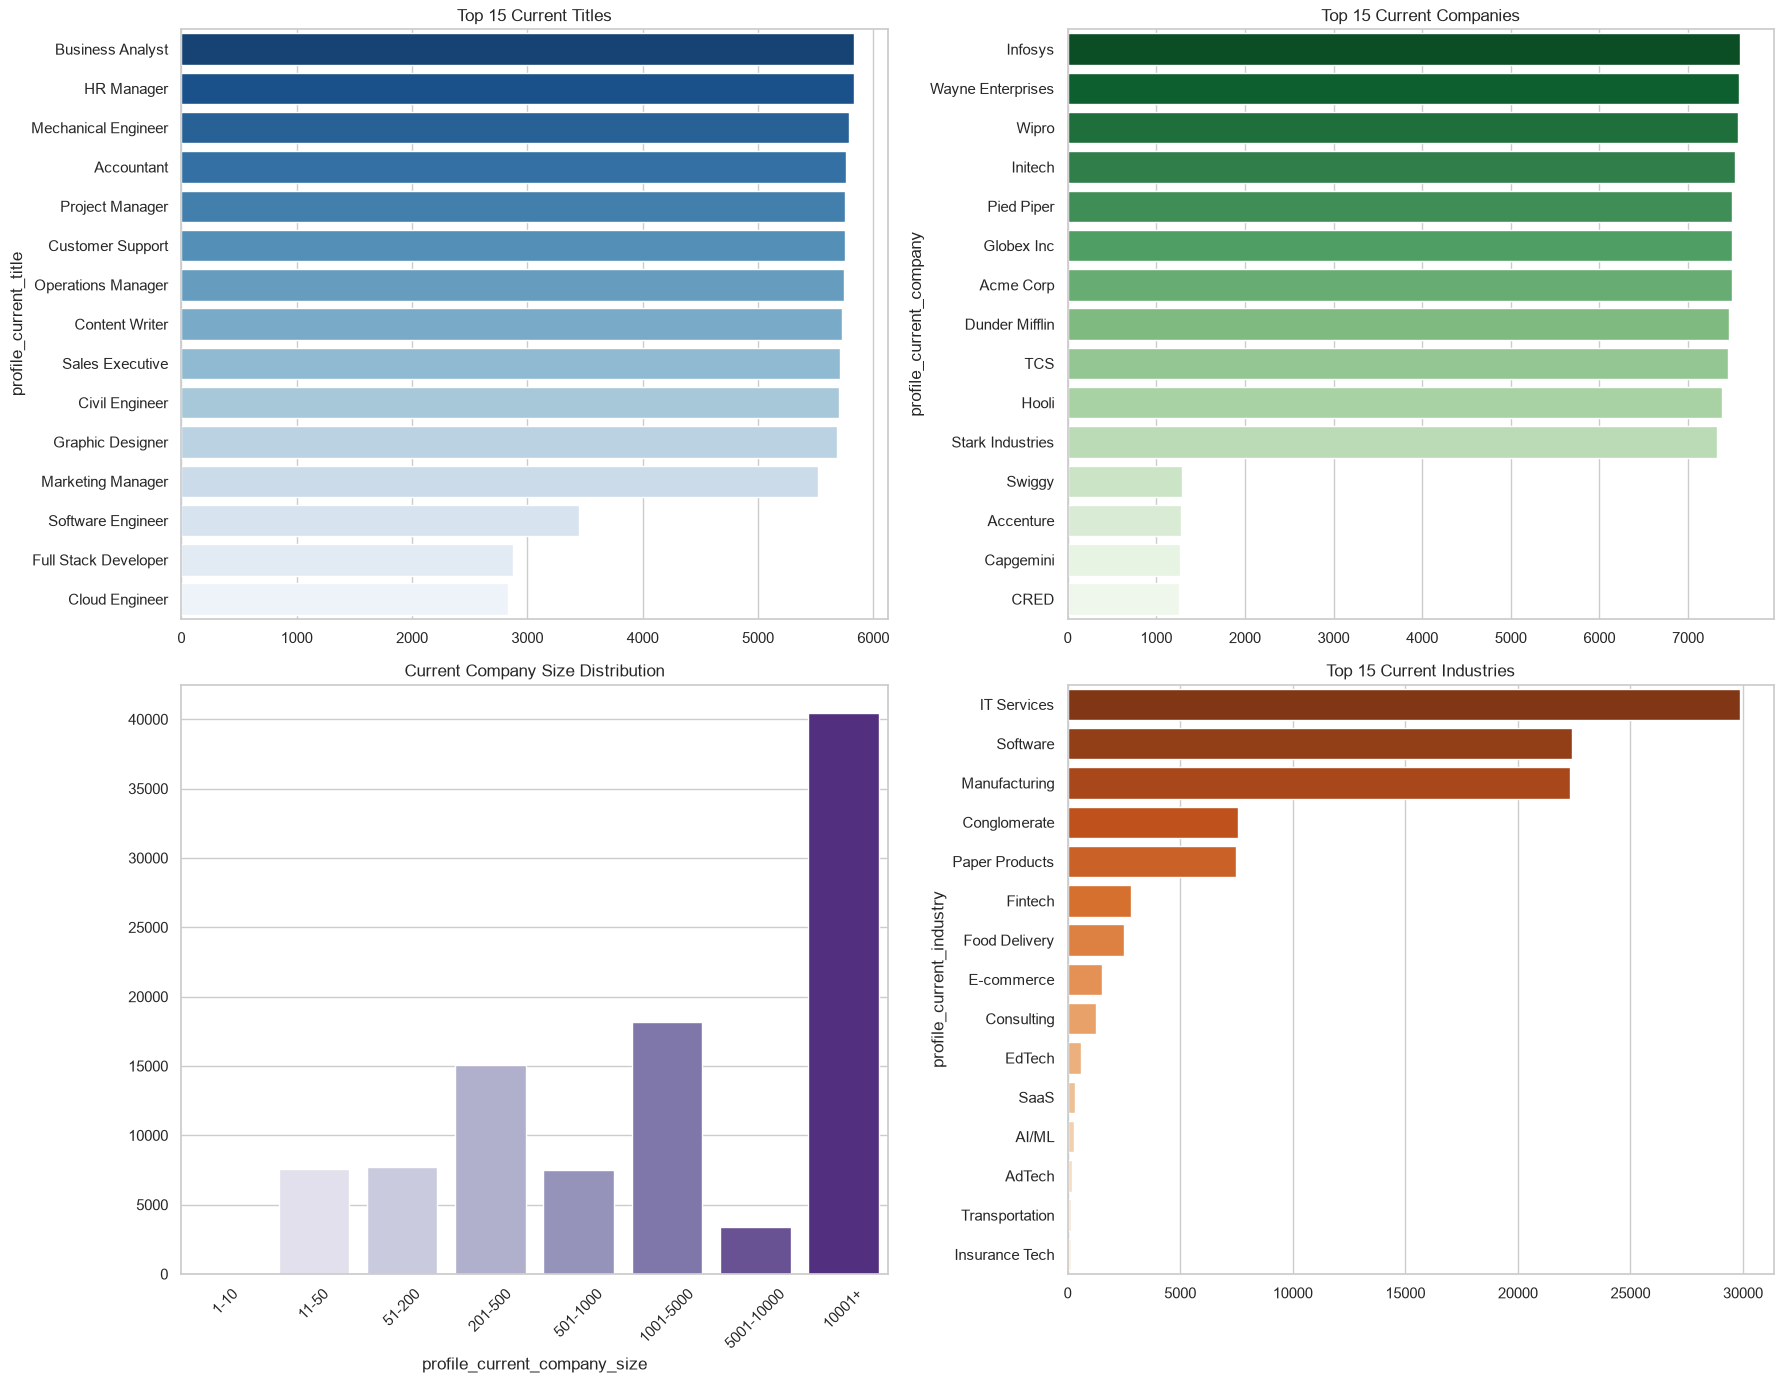

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

title_counts = df['profile_current_title'].value_counts().head(15)
sns.barplot(x=title_counts.values, y=title_counts.index, ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title('Top 15 Current Titles')

company_counts = df['profile_current_company'].value_counts().head(15)
sns.barplot(x=company_counts.values, y=company_counts.index, ax=axes[0, 1], palette="Greens_r")
axes[0, 1].set_title('Top 15 Current Companies')

size_order = ["1-10", "11-50", "51-200", "201-500", "501-1000", "1001-5000", "5001-10000", "10001+"]
size_counts = df['profile_current_company_size'].value_counts().reindex(size_order)
sns.barplot(x=size_counts.index, y=size_counts.values, ax=axes[1, 0], palette="Purples")
axes[1, 0].set_title('Current Company Size Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

industry_counts = df['profile_current_industry'].value_counts().head(15)
sns.barplot(x=industry_counts.values, y=industry_counts.index, ax=axes[1, 1], palette="Oranges_r")
axes[1, 1].set_title('Top 15 Current Industries')

plt.tight_layout()
plt.show()

## 6. Taxonomy Analysis: Company, Title & Industry Types (Item 6)

Extracting all unique company names, titles, and industries across both profiles and career histories.

In [7]:
all_companies = set(df['profile_current_company'].dropna())
all_titles = set(df['profile_current_title'].dropna())
all_industries = set(df['profile_current_industry'].dropna())

for career_history in df['career_history']:
    for job in career_history:
        if job.get('company'):
            all_companies.add(job['company'])
        if job.get('title'):
            all_titles.add(job['title'])
        if job.get('industry'):
            all_industries.add(job['industry'])

print(f"Total Unique Companies across dataset: {len(all_companies)}")
print(f"Total Unique Job Titles across dataset: {len(all_titles)}")
print(f"Total Unique Industries across dataset: {len(all_industries)}")

print("\n--- Sample of 15 Unique Job Titles ---")
print(list(all_titles)[:15])

Total Unique Companies across dataset: 63
Total Unique Job Titles across dataset: 48
Total Unique Industries across dataset: 24

--- Sample of 15 Unique Job Titles ---
['ML Engineer', 'Machine Learning Engineer', 'Data Scientist', 'Senior ML Engineer — Search & Ranking', 'Accountant', 'AI Research Engineer', 'Computer Vision Engineer', 'Senior Software Engineer (ML)', 'Mechanical Engineer', 'Content Writer', 'Senior NLP Engineer', 'Applied ML Engineer', 'Full Stack Developer', 'Backend Engineer', 'Senior Machine Learning Engineer']


## 7. Education Analysis: Degree & Field of Study (Item 7)

In [8]:
degrees = []
fields_of_study = []

for edu_list in df['education']:
    for edu in edu_list:
        if edu.get('degree'):
            degrees.append(edu['degree'].strip())
        if edu.get('field_of_study'):
            fields_of_study.append(edu['field_of_study'].strip())

degree_series = pd.Series(degrees)
field_series = pd.Series(fields_of_study)

print(f"Unique Degrees: {degree_series.nunique()}")
print(degree_series.value_counts().head(10))

print(f"\nUnique Fields of Study: {field_series.nunique()}")
print(field_series.value_counts().head(10))

Unique Degrees: 8
M.E.      17650
M.S.      17604
M.Sc      17562
M.Tech    17535
Ph.D      17526
B.Tech    17465
B.E.      17259
B.Sc      17177
Name: count, dtype: int64

Unique Fields of Study: 16


Information Technology     12328
Data Science               12222
Machine Learning           12216
Computer Engineering       12114
Artificial Intelligence    12009
Computer Science           11868
Statistics                  6762
Chemical Engineering        6740
Electronics                 6726
Physics                     6726
Name: count, dtype: int64


## 8. Skills Analysis (Item 8)

In [9]:
skills_list = []
for skill_arr in df['skills']:
    for s in skill_arr:
        if s.get('name'):
            skills_list.append(s['name'].strip())

skills_series = pd.Series(skills_list)
print(f"Total Unique Skills listed: {skills_series.nunique()}")
print("\n--- Top 25 Most Common Skills ---")
print(skills_series.value_counts().head(25))

Total Unique Skills listed: 133

--- Top 25 Most Common Skills ---
HTML                  12246
Databricks            12244
Redux                 12222
Terraform             12187
Angular               12173
Figma                 12157
Salesforce CRM        12157
Vue.js                12142
Sales                 12138
Accounting            12136
Agile                 12135
Kafka                 12114
Excel                 12109
BigQuery              12108
CI/CD                 12108
Project Management    12106
Airflow               12105
AWS                   12104
Flask                 12104
Scrum                 12083
Illustrator           12072
Kubernetes            12071
ETL                   12068
CSS                   12065
Docker                12062
Name: count, dtype: int64


## 9. Certifications & Languages Analysis (Item 9)

In [10]:
certs = []
issuers = []
languages = []

for cert_arr in df['certifications']:
    for c in cert_arr:
        if c.get('name'):
            certs.append(c['name'].strip())
        if c.get('issuer'):
            issuers.append(c['issuer'].strip())

for lang_arr in df['languages']:
    for l in lang_arr:
        if l.get('language'):
            languages.append(l['language'].strip())

cert_series = pd.Series(certs)
issuer_series = pd.Series(issuers)
lang_series = pd.Series(languages)

print(f"Unique Certifications: {cert_series.nunique()}")
print(cert_series.value_counts().head(10))

print(f"\nUnique Certification Issuers: {issuer_series.nunique()}")
print(issuer_series.value_counts().head(10))

print(f"\nUnique Languages Spoken: {lang_series.nunique()}")
print(lang_series.value_counts().head(10))

Unique Certifications: 8
AWS Certified Cloud Practitioner             12499
Six Sigma Green Belt                         12280
Scrum Master Certified                       12147
AWS Certified Machine Learning Specialty       131
Deep Learning Specialization                   111
Google Cloud Professional ML Engineer          111
NLP Specialization                             105
LangChain for LLM Application Development      100
Name: count, dtype: int64

Unique Certification Issuers: 6
AWS                         12630
ASQ                         12280
Scrum Alliance              12147
Coursera/DeepLearning.AI      216
Google Cloud                  111
DeepLearning.AI               100
Name: count, dtype: int64

Unique Languages Spoken: 2
English    100000
Hindi      100000
Name: count, dtype: int64


## 10. Redrob Signals Overview & Summary Statistics

In [11]:
numerical_cols = [
    'signal_profile_completeness_score', 'signal_profile_views_received_30d', 
    'signal_applications_submitted_30d', 'signal_recruiter_response_rate', 
    'signal_avg_response_time_hours', 'signal_connection_count', 
    'signal_endorsements_received', 'signal_notice_period_days', 
    'signal_github_activity_score', 'signal_search_appearance_30d', 
    'signal_saved_by_recruiters_30d', 'signal_interview_completion_rate', 
    'signal_offer_acceptance_rate'
]

print("--- Redrob Signals Numerical Columns Descriptive Statistics ---")
print(df[numerical_cols].describe().T)

--- Redrob Signals Numerical Columns Descriptive Statistics ---
                                      count        mean         std    min  \
signal_profile_completeness_score  100000.0   56.758180   17.274069  25.00   
signal_profile_views_received_30d  100000.0   47.985250   32.051870   0.00   
signal_applications_submitted_30d  100000.0    5.390360    3.494796   0.00   
signal_recruiter_response_rate     100000.0    0.436574    0.214122   0.02   
signal_avg_response_time_hours     100000.0  132.702744   75.238241   2.10   
signal_connection_count            100000.0  345.664890  208.145694  10.00   
signal_endorsements_received       100000.0   30.068570   20.242847   0.00   
signal_notice_period_days          100000.0   87.385800   36.589628   0.00   
signal_github_activity_score       100000.0    9.619230   17.761394  -1.00   
signal_search_appearance_30d       100000.0  117.543800   92.825891   0.00   
signal_saved_by_recruiters_30d     100000.0    7.658700    5.921436   0.00   


## 11. Date Validation: Signup vs. Last Active

In [12]:
df['signup_dt'] = pd.to_datetime(df['signal_signup_date'])
df['last_active_dt'] = pd.to_datetime(df['signal_last_active_date'])
date_order_violations = df[df['last_active_dt'] < df['signup_dt']]

print(f"Signup date range: {df['signal_signup_date'].min()} to {df['signal_signup_date'].max()}")
print(f"Last active date range: {df['signal_last_active_date'].min()} to {df['signal_last_active_date'].max()}")
print(f"Date Order Violations (last_active_date < signup_date): {len(date_order_violations)}")

Signup date range: 2022-04-18 to 2026-05-22


Last active date range: 2025-09-29 to 2026-05-27
Date Order Violations (last_active_date < signup_date): 7496


## 12. Financial Metrics: Expected Salary Ranges

Salary Range Violations (min > max): 18865
Expected Salary Min (LPA): 3.0 to 49.7
Expected Salary Max (LPA): 6.0 to 74.5


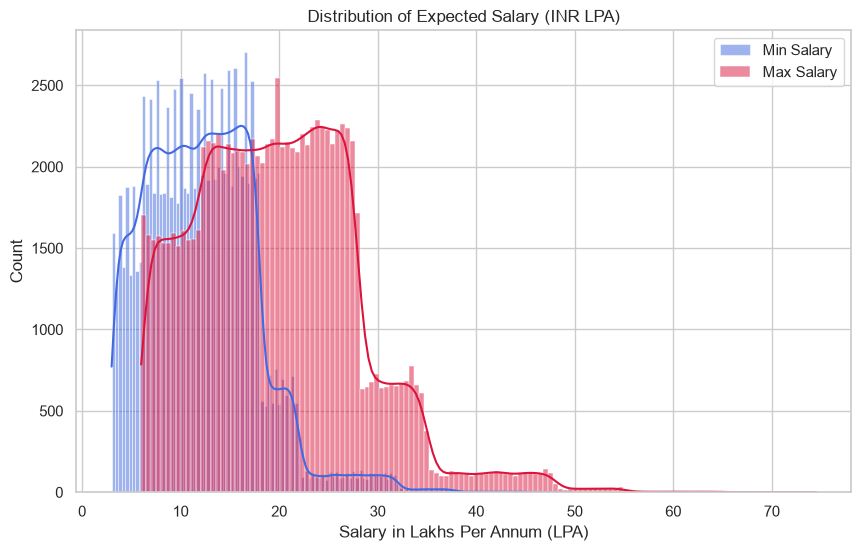

In [13]:
salary_violations = df[df['expected_salary_min'] > df['expected_salary_max']]
print(f"Salary Range Violations (min > max): {len(salary_violations)}")
print(f"Expected Salary Min (LPA): {df['expected_salary_min'].min()} to {df['expected_salary_min'].max()}")
print(f"Expected Salary Max (LPA): {df['expected_salary_max'].min()} to {df['expected_salary_max'].max()}")

plt.figure(figsize=(10, 6))
sns.histplot(df['expected_salary_min'], color='royalblue', label='Min Salary', kde=True, alpha=0.5)
sns.histplot(df['expected_salary_max'], color='crimson', label='Max Salary', kde=True, alpha=0.5)
plt.title('Distribution of Expected Salary (INR LPA)')
plt.xlabel('Salary in Lakhs Per Annum (LPA)')
plt.legend()
plt.show()

## 13. Activity & Performance Rates

Candidates with no GitHub linked (-1): 64637 (64.64%)
Candidates with no offer history (-1): 59554 (59.55%)


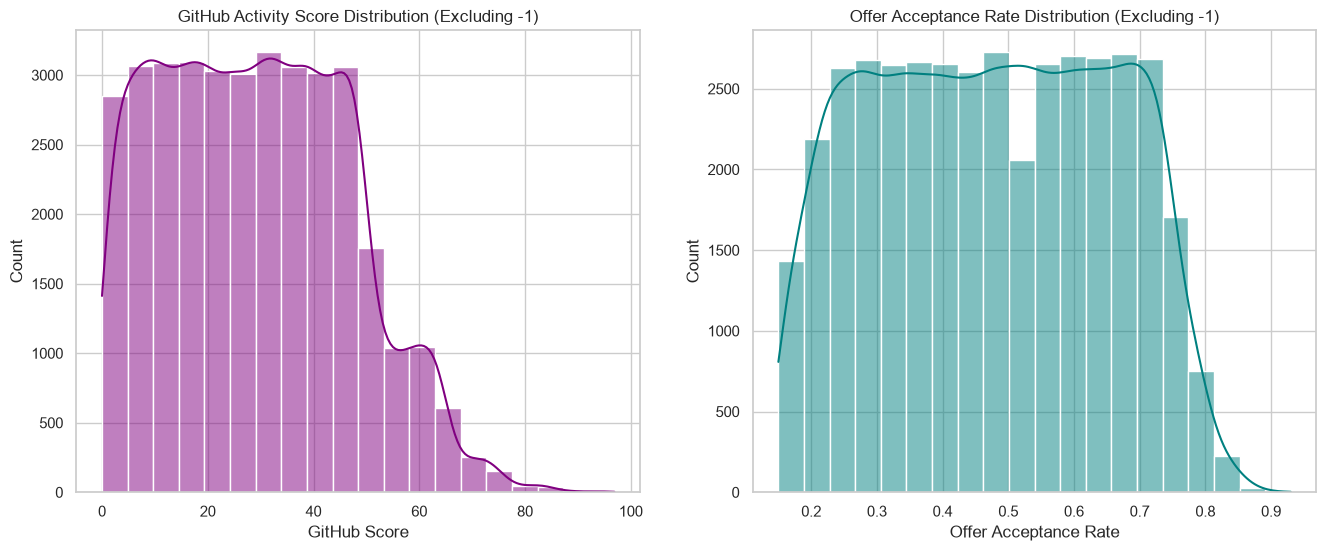

In [14]:
github_scores = df['signal_github_activity_score']
print(f"Candidates with no GitHub linked (-1): {github_scores.eq(-1).sum()} ({github_scores.eq(-1).mean()*100:.2f}%)")

offer_acceptance = df['signal_offer_acceptance_rate']
print(f"Candidates with no offer history (-1): {offer_acceptance.eq(-1).sum()} ({offer_acceptance.eq(-1).mean()*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(github_scores[github_scores >= 0], bins=20, kde=True, ax=axes[0], color='purple')
axes[0].set_title('GitHub Activity Score Distribution (Excluding -1)')
axes[0].set_xlabel('GitHub Score')

sns.histplot(offer_acceptance[offer_acceptance >= 0], bins=20, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Offer Acceptance Rate Distribution (Excluding -1)')
axes[1].set_xlabel('Offer Acceptance Rate')
plt.show()

## 14. Categorical Preferences & Profile Verification Flags

C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\1562482256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='signal_preferred_work_mode', data=df, ax=axes[0, 0], palette="Set2")
C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\1562482256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='signal_open_to_work_flag', data=df, ax=axes[0, 1], palette="Set2")


C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\1562482256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='signal_willing_to_relocate', data=df, ax=axes[0, 2], palette="Set2")
C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\1562482256.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='signal_verified_email', data=df, ax=axes[1, 0], palette="Set2")
C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\1562482256.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='signal_verified_phone', data=df, ax=axes[1, 1], palette="S

C:\Users\conqu\AppData\Local\Temp\ipykernel_36976\1562482256.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='signal_linkedin_connected', data=df, ax=axes[1, 2], palette="Set2")


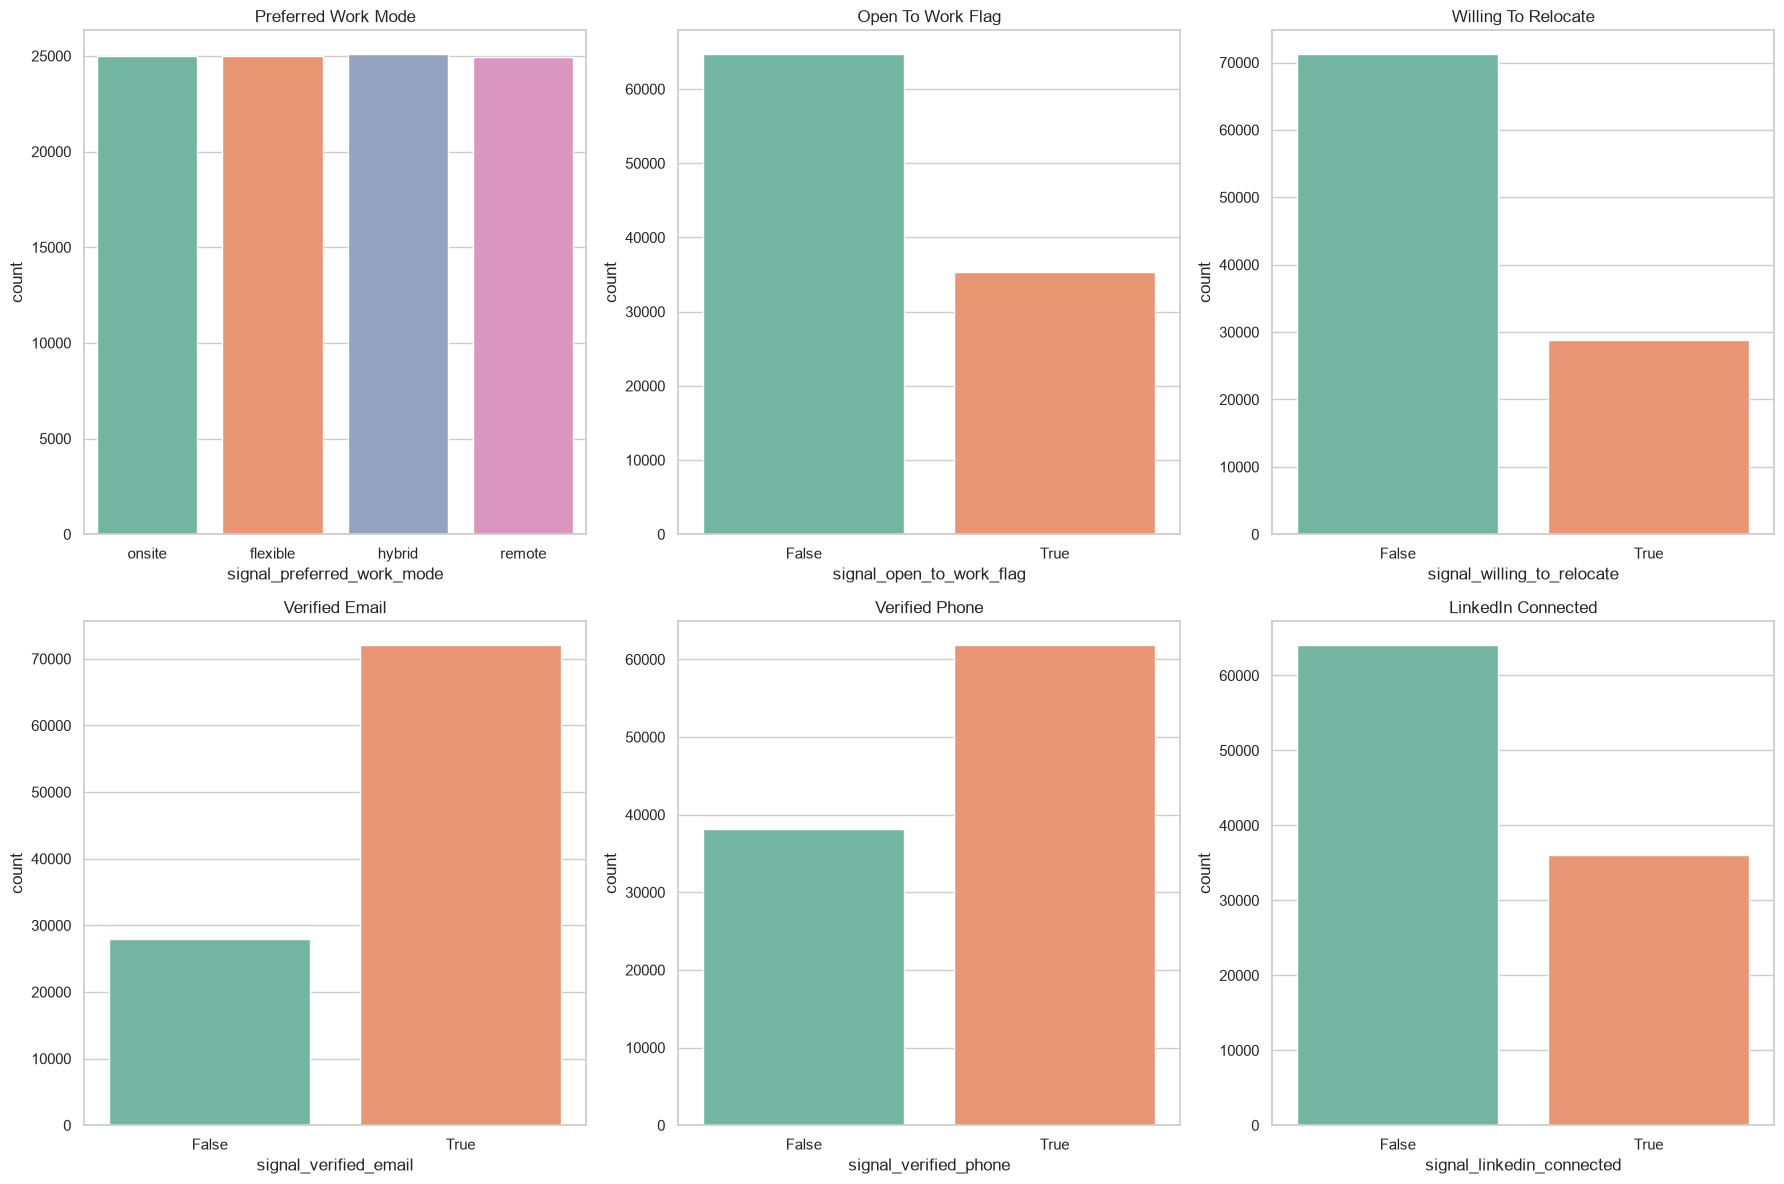

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.countplot(x='signal_preferred_work_mode', data=df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title('Preferred Work Mode')

sns.countplot(x='signal_open_to_work_flag', data=df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title('Open To Work Flag')

sns.countplot(x='signal_willing_to_relocate', data=df, ax=axes[0, 2], palette="Set2")
axes[0, 2].set_title('Willing To Relocate')

sns.countplot(x='signal_verified_email', data=df, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title('Verified Email')

sns.countplot(x='signal_verified_phone', data=df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title('Verified Phone')

sns.countplot(x='signal_linkedin_connected', data=df, ax=axes[1, 2], palette="Set2")
axes[1, 2].set_title('LinkedIn Connected')

plt.tight_layout()
plt.show()

## 15. Skill Assessments Deep-Dive

In [16]:
print(f"Total candidates with at least one assessment: {df['signal_assessments_taken'].gt(0).sum()} ({df['signal_assessments_taken'].gt(0).mean()*100:.2f}%)")
print(f"Average assessments taken per candidate: {df['signal_assessments_taken'].mean():.2f}")
print(f"Average score of completed assessments: {df['signal_avg_assessment_score'].mean():.2f}")

assessed_skills = []
assessed_scores = []
for scores_dict in df['skill_assessment_scores']:
    if isinstance(scores_dict, dict):
        for skill, score in scores_dict.items():
            assessed_skills.append(skill)
            assessed_scores.append(score)

assessed_df = pd.DataFrame({'skill': assessed_skills, 'score': assessed_scores})
print(f"\nTotal Unique Assessed Skills: {assessed_df['skill'].nunique()}")
print("\n--- Top 10 Most Frequently Assessed Skills ---")
print(assessed_df['skill'].value_counts().head(10))

print("\n--- Average Scores by Top Assessed Skills ---")
print(assessed_df.groupby('skill')['score'].mean().loc[assessed_df['skill'].value_counts().head(10).index])

Total candidates with at least one assessment: 24244 (24.24%)
Average assessments taken per candidate: 0.36
Average score of completed assessments: 51.16

Total Unique Assessed Skills: 56

--- Top 10 Most Frequently Assessed Skills ---
skill
YOLO                   1195
Feature Engineering    1174
CNN                    1174
Weights & Biases       1173
Forecasting            1167
Speech Recognition     1159
MLOps                  1159
BentoML                1157
OpenCV                 1155
Data Science           1147
Name: count, dtype: int64

--- Average Scores by Top Assessed Skills ---
skill
YOLO                   52.024017
Feature Engineering    51.951022
CNN                    51.285434
Weights & Biases       51.987980
Forecasting            51.269580
Speech Recognition     51.784642
MLOps                  52.608110
BentoML                51.582800
OpenCV                 52.193593
Data Science           51.063557
Name: score, dtype: float64


## 16. Redrob Signals Correlation & Logical Anomalies

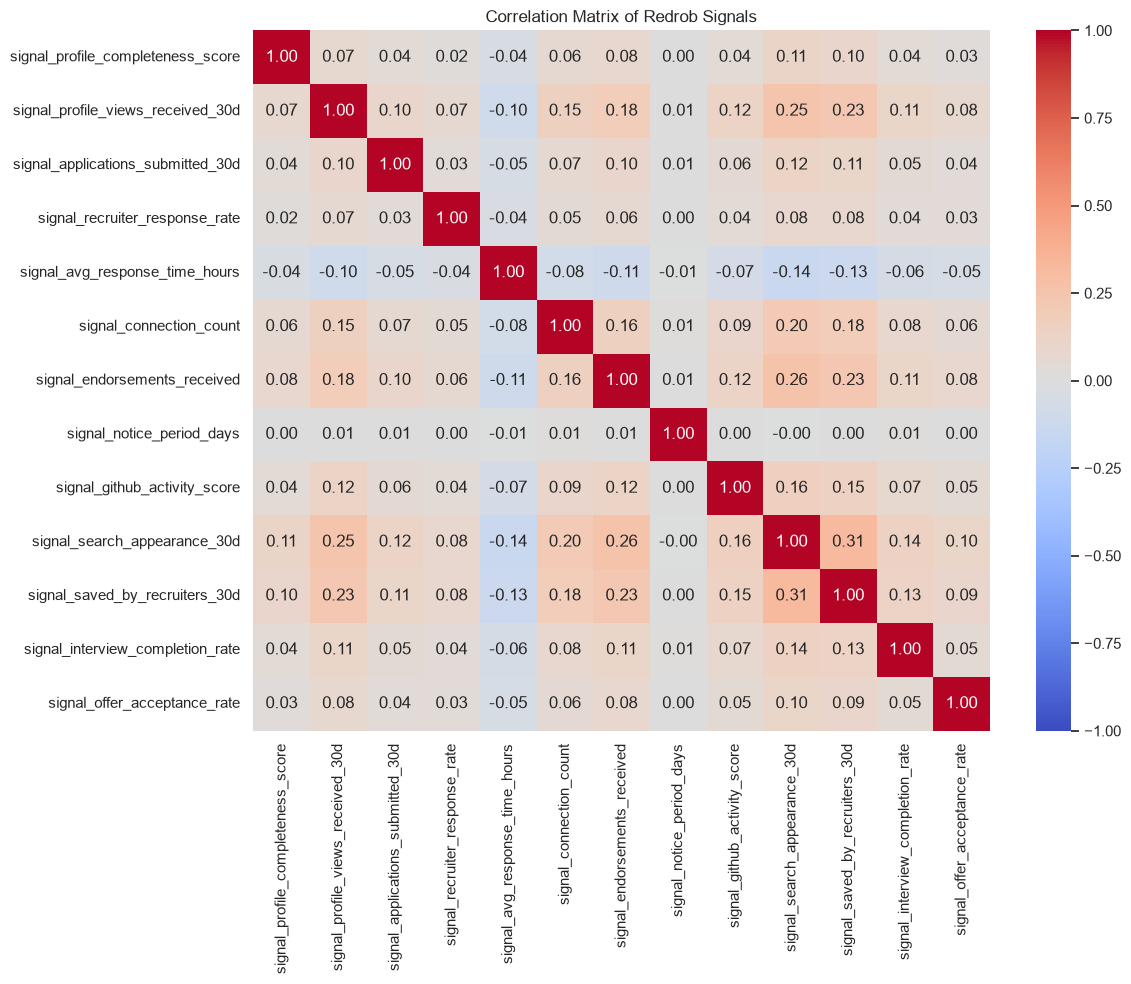

Candidates with <10% completeness but actively applying: 0
Candidates with 100% response rate but average response time > 1 week: 0


In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Redrob Signals')
plt.tight_layout()
plt.show()

# Check logical contradictions / potential bot accounts
no_comp_active = df[(df['signal_profile_completeness_score'] < 10) & (df['signal_applications_submitted_30d'] > 0)]
print(f"Candidates with <10% completeness but actively applying: {len(no_comp_active)}")

slow_responders = df[(df['signal_recruiter_response_rate'] == 1.0) & (df['signal_avg_response_time_hours'] > 168)]
print(f"Candidates with 100% response rate but average response time > 1 week: {len(slow_responders)}")

## Summary of Key Anomalies

Based on the analysis, here is the count and percentage of logical anomalies found in the dataset:

| Anomaly Type | Description | Count | Percentage of Dataset |
| :--- | :--- | :--- | :--- |
| **Date Order Violations** | last_active_date is before signup_date | 7,496 | 7.50% |
| **Salary Range Violations** | Minimum expected salary is greater than maximum (min > max) | 18,865 | 18.87% |
| **Neither Email nor Phone Verified** | Candidate has verified_email and verified_phone both set to False | 10,738 | 10.74% |
